# Dynamics of Hallucination Propagation in Multi-Agent LLM Collaboration on Graph Topologies with Penalty-Based Enforcement

*Large Language Models (LLMs) have demonstrated exceptional capabilities, but their deployment in safety-critical environments is significantly hindered by their tendency to hallucinate and generate factually unsupported outputs. Existing detection methods often rely on fallible LLM evaluators, which cannot guarantee the reliability of the evaluating mechanism itself and leads to an infinite regress of trust. To address this, this project investigates the dynamics of hallucination propagation and self-correction in multi-agent LLM collaboration. We conduct an empirical study of opinion formation across 50-node Erd˝os-R´enyi random graphs to demonstrate how network topology influences multi-round discussions among architecturally diverse LLM agents (Llama 3.2, Qwen 2.5, and Mistral). To ensure reliable accountability and rigorous groundtruth validation without relying solely on automated LLM judges, we integrate a Solidity smart contract-based audit and reputation system. This blockchain infrastructure provides tamper-resistant, penalty-weighted accountability for each agent, producing quantitative reliability and trust scores from immutable on-chaindata recorded on a local Ethereum test chain. Experimental results demonstrate that denser network topologies accelerate convergence toward factual accuracy, and that the behavioral signals emerging from topology-constrained discussions carry substantial information about agent reliability independent of any automated detection mechanism.*

**GamePlan:**
  



1.   User prompt input
1.   Agents answers (initial answer)
2.   All answers are now shared based on topology
1.   Compute evalution based on system prompt(refer evaulte function)
2.   itterate till desired rounds (change rounuds value in run_pipline function)
1.   collect outputs in a csv file(easy for comparision with response and ground_truth)
2.   Manual decision making (yes/no editing on csv)
1.   visualize on a heatmap




Dependencies


---Installing Ollama



In [ ]:
!apt-get install -y zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
genai.configure(api_key=" API")

In [ ]:
!curl -fsSL http://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.




---Starting Ollama Server



Remove OLLAMA_NUM_GPU if you are using CPU

In [ ]:
import subprocess
import time
import os


subprocess.Popen(["ollama","serve"],env={**os.environ, "OLLAMA_NUM_GPU": "1"})
time.sleep(3)
print("Ollama server started")

Ollama server started




---Pull Models



In [ ]:
!ollama pull llama3.2
!ollama pull qwen2.5
!ollama pull mistral
#!ollama pull gemma
#!ollama pull qwen3.5
#!ollama pull mistral-small3.2




---To handel Prompts


In [ ]:
import requests

def call_ollama(model: str,prompt: str,stream : bool):
  data = {
      "model": model,
      "prompt": prompt,
      "stream": stream
  }
  response = requests.post("http://localhost:11434/api/generate", json=data)
  result = response.json()


  return result["response"]

Gemeni models are just integrated as an option for future integrations

In [ ]:
import google.generativeai as genai
import time

genai.configure(api_key="APi")

def call_gemini(model: str, prompt: str, retries=5, wait=30):
    gemini_model = genai.GenerativeModel(model)
    for attempt in range(retries):
        try:
            response = gemini_model.generate_content(prompt)
            return response.text
        except Exception as e:
            if "429" in str(e):
                if attempt < retries - 1:
                    print(f"Rate limited. Waiting {wait}s... (attempt {attempt+1}/{retries})")
                    time.sleep(wait)
                    wait *= 2
                else:
                    print("Max retries reached.")
                    return "Rate limit exceeded - no response"
            else:
                raise

In [ ]:
def call_gemini(model: str, prompt: str):
    gemini_model = genai.GenerativeModel(model)
    response = gemini_model.generate_content(prompt)
    return response.text

In [ ]:
def call_gemini(model: str, prompt: str):
    data = {
        "contents": [{"parts": [{"text": prompt}]}]
    }
    api_key = " "  #API
    response = requests.post(
        f"https://generativelanguage.googleapis.com/v1beta/models/{model}:generateContent?key={api_key}",
        json=data
    )
    result = response.json()
    print(result)
    return result["candidates"][0]["content"]["parts"][0]["text"]




---Node Behaviour



In [ ]:
gemini_models = {"gemini-2.0-flash", "gemini-1.5-pro", "gemini-1.5-flash", "gemini-2.5-pro"}

def call_model(model: str, prompt: str):

    if model in gemini_models:
        return call_gemini(model, prompt)
    else:
        return call_ollama(model, prompt, False)

class Node:

  def __init__(self, node_id, model="llama3.2", prompt_family="A"):
    self.node_id = node_id
    self.model = model
    self.current_answer = ""
    self.prompt_family = prompt_family

  def generate(self, question):
    prompt = f"You are Node {self.node_id} (model: {self.model}). Answer this question: {question}"
    self.current_answer = call_model(self.model, prompt)
    return self.current_answer

  def evaluate(self, question, neighbor_answers, round_num):
    lines=[]

    for node, answer in neighbor_answers.items():
        lines.append(f"{node}: {answer}")

    formatted_answers = "\n".join(lines)

    if self.prompt_family == "A" or round_num == 1 :

      prompt = f"""You are Node {self.node_id} (model: {self.model}). The original question was: {question}

      -Here is your current answer: {self.current_answer}
      -Here are your neighbors' answers: {formatted_answers}
      -Re-evaluate your answer. If you are wrong, correct it.
      -Respond with your final answer only, nothing else.
      """
    else:
      prompt = f"""Here are multiple agents' answers to "{question}" : {formatted_answers}
      - Merge into a single improved answer"""

    evaluation = call_model(self.model, prompt)
    self.current_answer = evaluation

    print(f"--- Node {self.node_id} ({self.model}) updated answer: {self.current_answer}")
    return evaluation



---Topology



In [ ]:
import random

def complete_mesh_graph(node_ids):
    graph={}
    for nid in node_ids:
        neighbors = []
        for other in node_ids:
            if other != nid:
                neighbors.append(other)
        graph[nid] = neighbors
    return graph

def star_graph(node_ids):
    hub = node_ids[0]
    leaves = node_ids[1:]
    graph = {hub: leaves}
    for leaf in leaves:
        graph[leaf] = [hub]
    return graph

def ring_graph(node_ids):
    n = len(node_ids)
    graph = {}
    for i in range(n):
      prev_node = node_ids[(i - 1) % n]
      next_node = node_ids[(i + 1) % n]
      graph[node_ids[i]] = [prev_node, next_node]
    return graph

def random_graph(node_ids, edge_probability=0.03):
    graph = {}

    for nid in node_ids:
      graph[nid]=[]

    for i in range(len(node_ids)):
        for j in range(i+1, len(node_ids)):
            if random.random() < edge_probability:
                graph[node_ids[i]].append(node_ids[j])
                graph[node_ids[j]].append(node_ids[i])
    return graph




---For finding the most connected node cluster



In [ ]:
import networkx as nx
import numpy as np

def get_largest_component(graph, edge_probability, n):
    c = edge_probability * (n - 1)
    sizes = []
    for i in range(1000):
        G = nx.fast_gnp_random_graph(n, c/(n-1))
        size = len(nx.node_connected_component(G, 1))
        sizes.append(size)

    average = np.mean(sizes)
    print(f"c value: {c:.2f}")
    print(f"Average component size over 1000 experiments: {average:.2f}")

    if c < 1:
        print(f"Theoretical expectation: {1/(1-c):.2f}")
    else:
        print("c >= 1: giant component expected")

    G = nx.Graph(graph)
    largest = max(nx.connected_components(G), key=len)

    print(f"Total nodes: {len(graph)}")
    print(f"Nodes in largest component: {len(largest)}")
    print(f"Isolated nodes excluded: {len(graph) - len(largest)}")

    return list(largest)




---Create Nodes



In [ ]:
def create_nodes(node_configs=None,prompt_family="B"):
  nodes=[]

  if node_configs is None:
        node_configs = [
    {"id": 1, "model": "llama3.2"},
    {"id": 2, "model": "qwen2.5"},
    {"id": 3, "model": "mistral"},
    {"id": 4, "model": "llama3.2"},
    {"id": 5, "model": "qwen2.5"},
    {"id": 6, "model": "mistral"},
    {"id": 7, "model": "llama3.2"},
    {"id": 8, "model": "qwen2.5"},
    {"id": 9, "model": "mistral"},
    {"id": 10, "model": "llama3.2"},
    {"id": 11, "model": "qwen2.5"},
    {"id": 12, "model": "mistral"},
    {"id": 13, "model": "llama3.2"},
    {"id": 14, "model": "qwen2.5"},
    {"id": 15, "model": "mistral"},
    {"id": 16, "model": "llama3.2"},
    {"id": 17, "model": "qwen2.5"},
    {"id": 18, "model": "mistral"},
    {"id": 19, "model": "llama3.2"},
    {"id": 20, "model": "qwen2.5"},
    {"id": 21, "model": "mistral"},
    {"id": 22, "model": "llama3.2"},
    {"id": 23, "model": "qwen2.5"},
    {"id": 24, "model": "mistral"},
    {"id": 25, "model": "llama3.2"},
    {"id": 26, "model": "qwen2.5"},
    {"id": 27, "model": "mistral"},
    {"id": 28, "model": "llama3.2"},
    {"id": 29, "model": "qwen2.5"},
    {"id": 30, "model": "mistral"},
    {"id": 31, "model": "llama3.2"},
    {"id": 32, "model": "qwen2.5"},
    {"id": 33, "model": "mistral"},
    {"id": 34, "model": "llama3.2"},
    {"id": 35, "model": "qwen2.5"},
    {"id": 36, "model": "mistral"},
    {"id": 37, "model": "llama3.2"},
    {"id": 38, "model": "qwen2.5"},
    {"id": 39, "model": "mistral"},
    {"id": 40, "model": "llama3.2"},
    {"id": 41, "model": "qwen2.5"},
    {"id": 42, "model": "mistral"},
    {"id": 43, "model": "llama3.2"},
    {"id": 44, "model": "qwen2.5"},
    {"id": 45, "model": "mistral"},
    {"id": 46, "model": "llama3.2"},
    {"id": 47, "model": "qwen2.5"},
    {"id": 48, "model": "mistral"},
    {"id": 49, "model": "llama3.2"},
    {"id": 50, "model": "qwen2.5"},




]
  for config in node_configs:
    node = Node(config["id"], config["model"], prompt_family)
    nodes.append(node)

  return nodes



In [ ]:
nodes = create_nodes()

for node in nodes:
    print(f"Node ID: {node.node_id}, Model: {node.model}")

Node ID: 1, Model: llama3.2
Node ID: 2, Model: qwen2.5
Node ID: 3, Model: mistral
Node ID: 4, Model: llama3.2
Node ID: 5, Model: qwen2.5
Node ID: 6, Model: mistral
Node ID: 7, Model: llama3.2
Node ID: 8, Model: qwen2.5
Node ID: 9, Model: mistral
Node ID: 10, Model: llama3.2
Node ID: 11, Model: qwen2.5
Node ID: 12, Model: mistral
Node ID: 13, Model: llama3.2
Node ID: 14, Model: qwen2.5
Node ID: 15, Model: mistral
Node ID: 16, Model: llama3.2
Node ID: 17, Model: qwen2.5
Node ID: 18, Model: mistral
Node ID: 19, Model: llama3.2
Node ID: 20, Model: qwen2.5
Node ID: 21, Model: mistral
Node ID: 22, Model: llama3.2
Node ID: 23, Model: qwen2.5
Node ID: 24, Model: mistral
Node ID: 25, Model: llama3.2
Node ID: 26, Model: qwen2.5
Node ID: 27, Model: mistral
Node ID: 28, Model: llama3.2
Node ID: 29, Model: qwen2.5
Node ID: 30, Model: mistral
Node ID: 31, Model: llama3.2
Node ID: 32, Model: qwen2.5
Node ID: 33, Model: mistral
Node ID: 34, Model: llama3.2
Node ID: 35, Model: qwen2.5
Node ID: 36, Mode



---For sending prompts to all models and collecting them



In [ ]:
def broadcast(nodes, question):
    all_answers = {}
    for node in nodes:
        answer = node.generate(question)
        all_answers[f"Node {node.node_id}"] = answer
    return all_answers





---Main Orchestration



In [ ]:
def run_pipeline(question, ground_truth="12", hallucination ="" ,rounds=50, node_configs=None, graph_type="random",edge_probability=0.12,prompt_family="B"):
    import csv
    rows = []
    global graph
    global node_ids


    nodes = create_nodes(node_configs, prompt_family)
    node_ids = [node.node_id for node in nodes]

    if graph_type == "complete":
        graph = complete_mesh_graph(node_ids)
    elif graph_type == "star":
        graph = star_graph(node_ids)
    elif graph_type == "ring":
        graph = ring_graph(node_ids)
    elif graph_type == "random":
        graph = random_graph(node_ids,edge_probability)
        active_node_ids = get_largest_component(graph, edge_probability, len(node_ids))
        filtered_nodes = []
        for node in nodes:
            if node.node_id in active_node_ids:
                filtered_nodes.append(node)
        nodes = filtered_nodes

        filtered_graph = {}
        for k, v in graph.items():
            if k in active_node_ids:
                filtered_graph[k] = v
        graph = filtered_graph



    else:
        raise ValueError(f"Unknown graph_type: {graph_type}. Use complete, star, or ring.")

    print(f"Graph topology ({graph_type}): {graph}")


    all_answers = broadcast(nodes, question)

    print("\n ___ initial answer ___")
    for node in nodes:
        print(f"\nNode {node.node_id}: {all_answers[f'Node {node.node_id}']}")
        print("---")
        if True:
          rows.append({
              "round": 0,
              "node": node.node_id,
              "model": node.model,
              "answer": all_answers[f"Node {node.node_id}"],
              "ground_truth": ground_truth,
              "Hallucination": "",
              })



    for round_num in range(1, rounds+1):
        print(f"\n--- Round {round_num} ---")
        new_answers = {}

        for node in nodes:
            neighbor_ids = graph[node.node_id]
            neighbor_answers = {}
            for nid in neighbor_ids:
              neighbor_answers[f"Node {nid}"] = all_answers[f"Node {nid}"]

            evaluation = node.evaluate(question, neighbor_answers, round_num)
            print(f"\nNode {node.node_id} ({node.model}) Evaluation: {evaluation}")

            new_answers[f"Node {node.node_id}"] = node.current_answer

            if round_num % 5 ==0:
              rows.append({
                  "round": round_num,
                  "node": node.node_id,
                  "model": node.model,
                  "answer": node.current_answer,
                  "ground_truth": ground_truth,
                  "Hallucination": " ",
                })

        all_answers = new_answers

        print(f"\n ___ updated answers after round {round_num} ___")
        for node, answer in all_answers.items():
            print(f"\n{node}: {answer}")
            print("---")

    with open("pipeline_output.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["round", "node", "model", "answer","ground_truth","Hallucination"])
        writer.writeheader()
        writer.writerows(rows)

    print("\n Saved to pipeline_output.csv")

*This is a quantitative repeated-measures experiment focused exclusively on the current implementation. The study uses 50 agents across three category of ground-truth questions (Factual, Mathematical puzzles, Decoding).*

*Graphs: **Erd˝os-R´enyi** random with three densities. Procedure: Round 0 independent inference → neighbour exchange → majority merge with model weighting. 21 experimental runs in total (one run = one question on one density). The first experiment was conducted for 100 rounds but due to computational power restrictions all subsequent experiments were run for 50 rounds*



---Run Here



In [ ]:
run_pipeline(""" A number is multiplied by 9, then 36 is subtracted. The result is divided by 3 and equals 24. What is the number?""", prompt_family="B")

Streaming output truncated to the last 5000 lines.
     \]
   - Divide both sides by 9:
     \[
     x = \frac{108}{9} = 12
     \]

4. **Verify the solution:**
   Start with \( x = 12 \).
   - Multiply it by 9:
     \[
     12 \times 9 = 108
     \]
   - Subtract 36 from the result:
     \[
     108 - 36 = 72
     \]
   - Divide the result by 3:
     \[
     \frac{72}{3} = 24
     \]

Since all steps and verifications confirm that \( x = 12 \) satisfies the given conditions, we can conclude that the original number is indeed **$\boxed{12}$**.
--- Node 8 (qwen2.5) updated answer: To solve the problem "A number is multiplied by 9, then 36 is subtracted. The result is divided by 3 and equals 24," follow these streamlined steps:

1. **Define the variable:**
   Let \( x \) represent the original number.

2. **Set up the equation based on given conditions:**
   - First, multiply \( x \) by 9:
     \[
     y = 9x
     \]
   - Next, subtract 36 from this product to get a new variable \( z \):



---Download CSV file


In [ ]:
from google.colab import files
files.download("pipeline_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---Visualization







*Node structure*

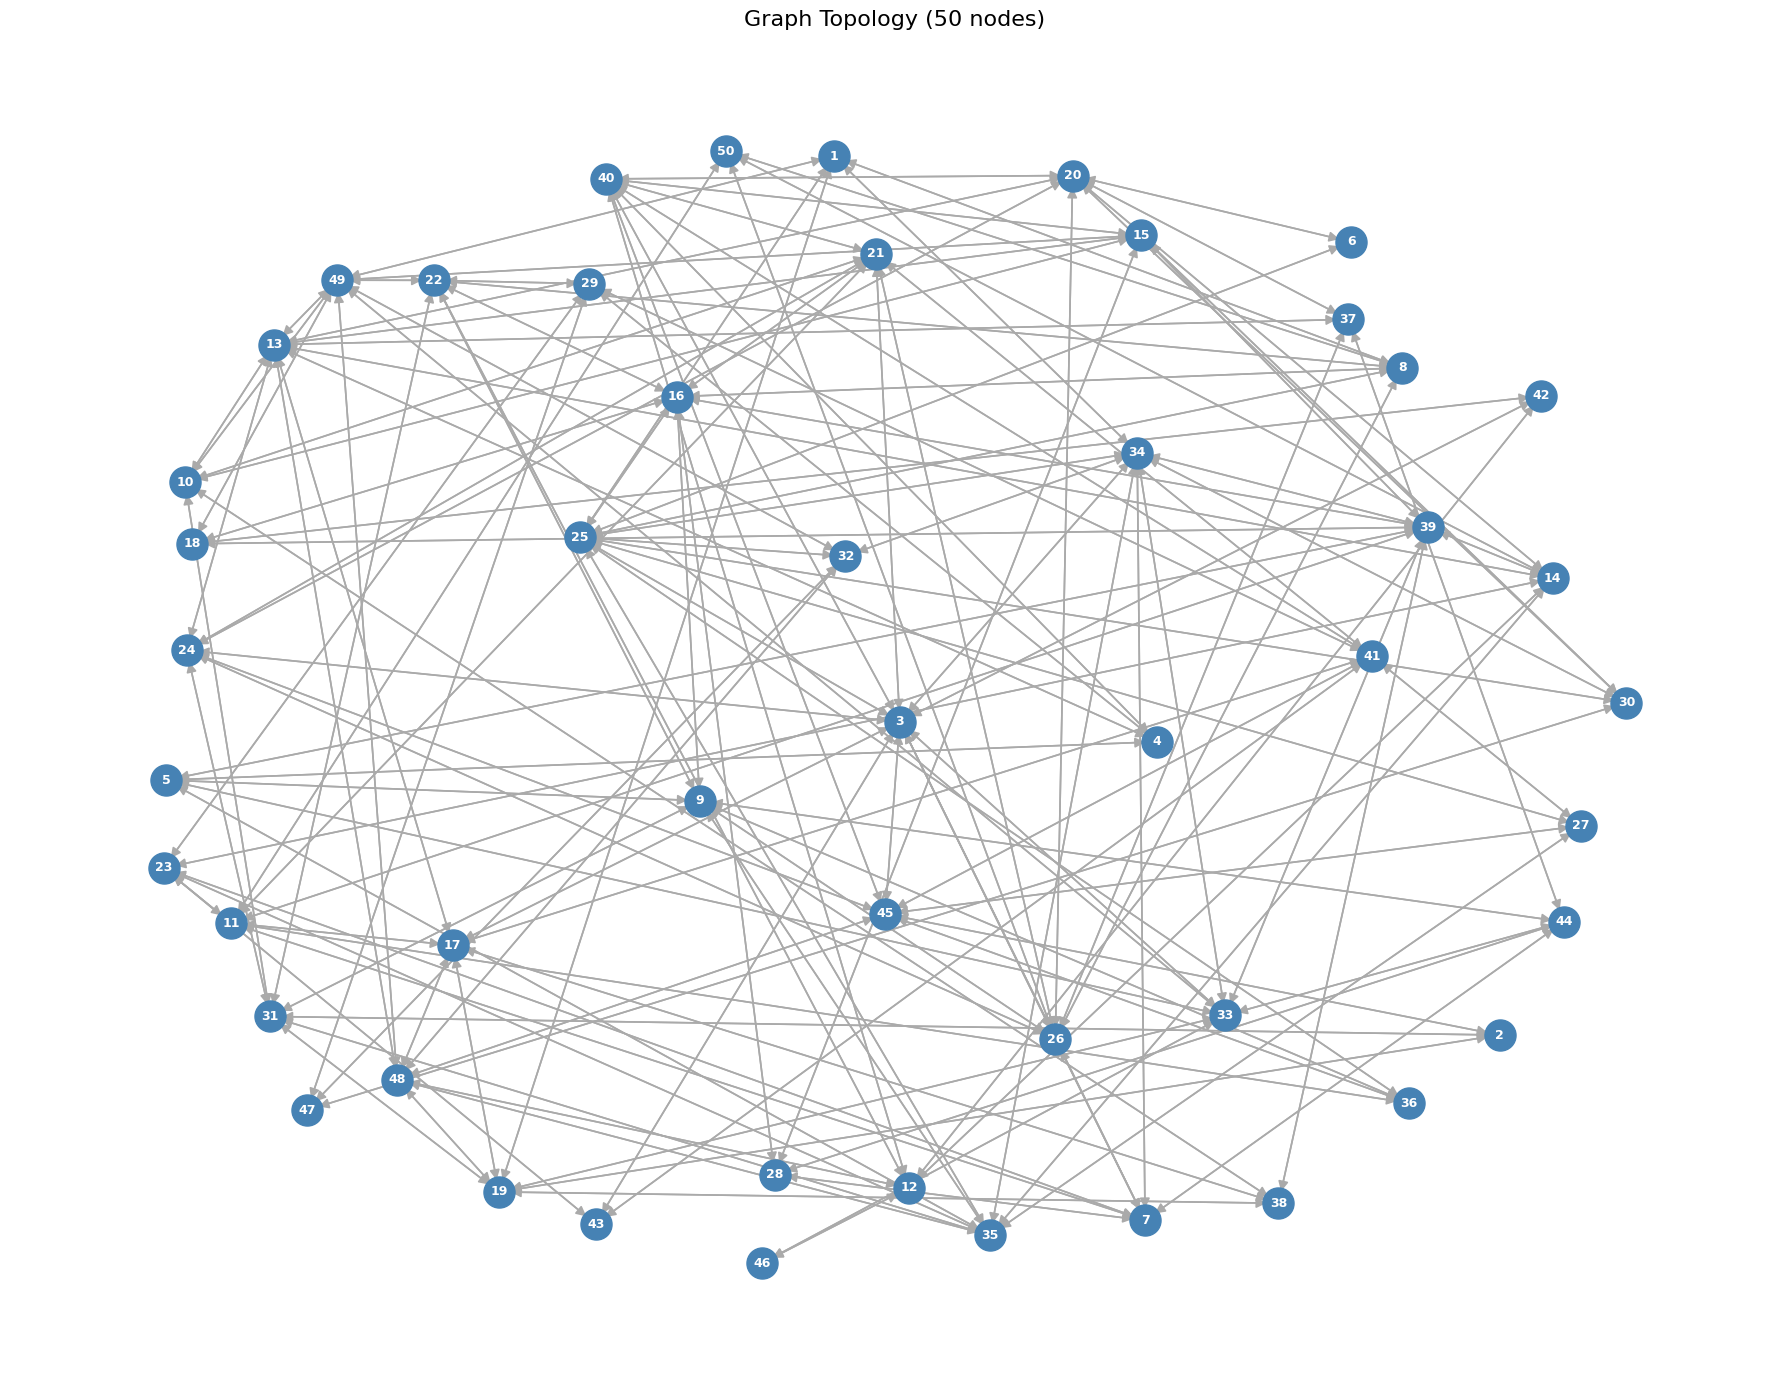

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for node, neighbors in graph.items():
    G.add_node(node)
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, seed=42, k=2)

isolated = [n for n in G.nodes if G.degree(n) == 0]
connected = [n for n in G.nodes if G.degree(n) > 0]

nx.draw_networkx_nodes(G, pos, nodelist=connected, node_color='steelblue', node_size=500)
nx.draw_networkx_nodes(G, pos, nodelist=isolated, node_color='lightgray', node_size=300)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15, edge_color='#aaaaaa', width=1.2)
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold')

plt.title("Graph Topology (50 nodes)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig("Nodes.png", dpi=150, bbox_inches="tight")
plt.show()

#Reference URL - https://network-science-notes.github.io/chapters/09-random-graphs.html#fig-branching

In [ ]:
from google.colab import files
files.download("Nodes.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

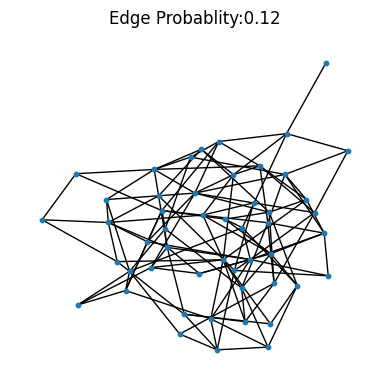

In [ ]:
import networkx as nx
from matplotlib import pyplot as plt

edge_probability=0.12
n = 50
c_value = edge_probability * (n - 1)

fig, ax = plt.subplots(figsize=(4, 4))

G_actual = nx.fast_gnp_random_graph(n, c_value/(n-1))
nx.draw(G_actual, ax=ax, node_size=10)
ax.set(title=f"Edge Probablity:{edge_probability}")

plt.tight_layout()
plt.savefig("Graph.png", dpi=150, bbox_inches="tight")
plt.show()

#Reference - https://network-science-notes.github.io/chapters/09-random-graphs.html#fig-branching

In [ ]:
from google.colab import files
files.download("Graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---HeatMap

*Showcasing Hallucinations across Nodes VS Rounds*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

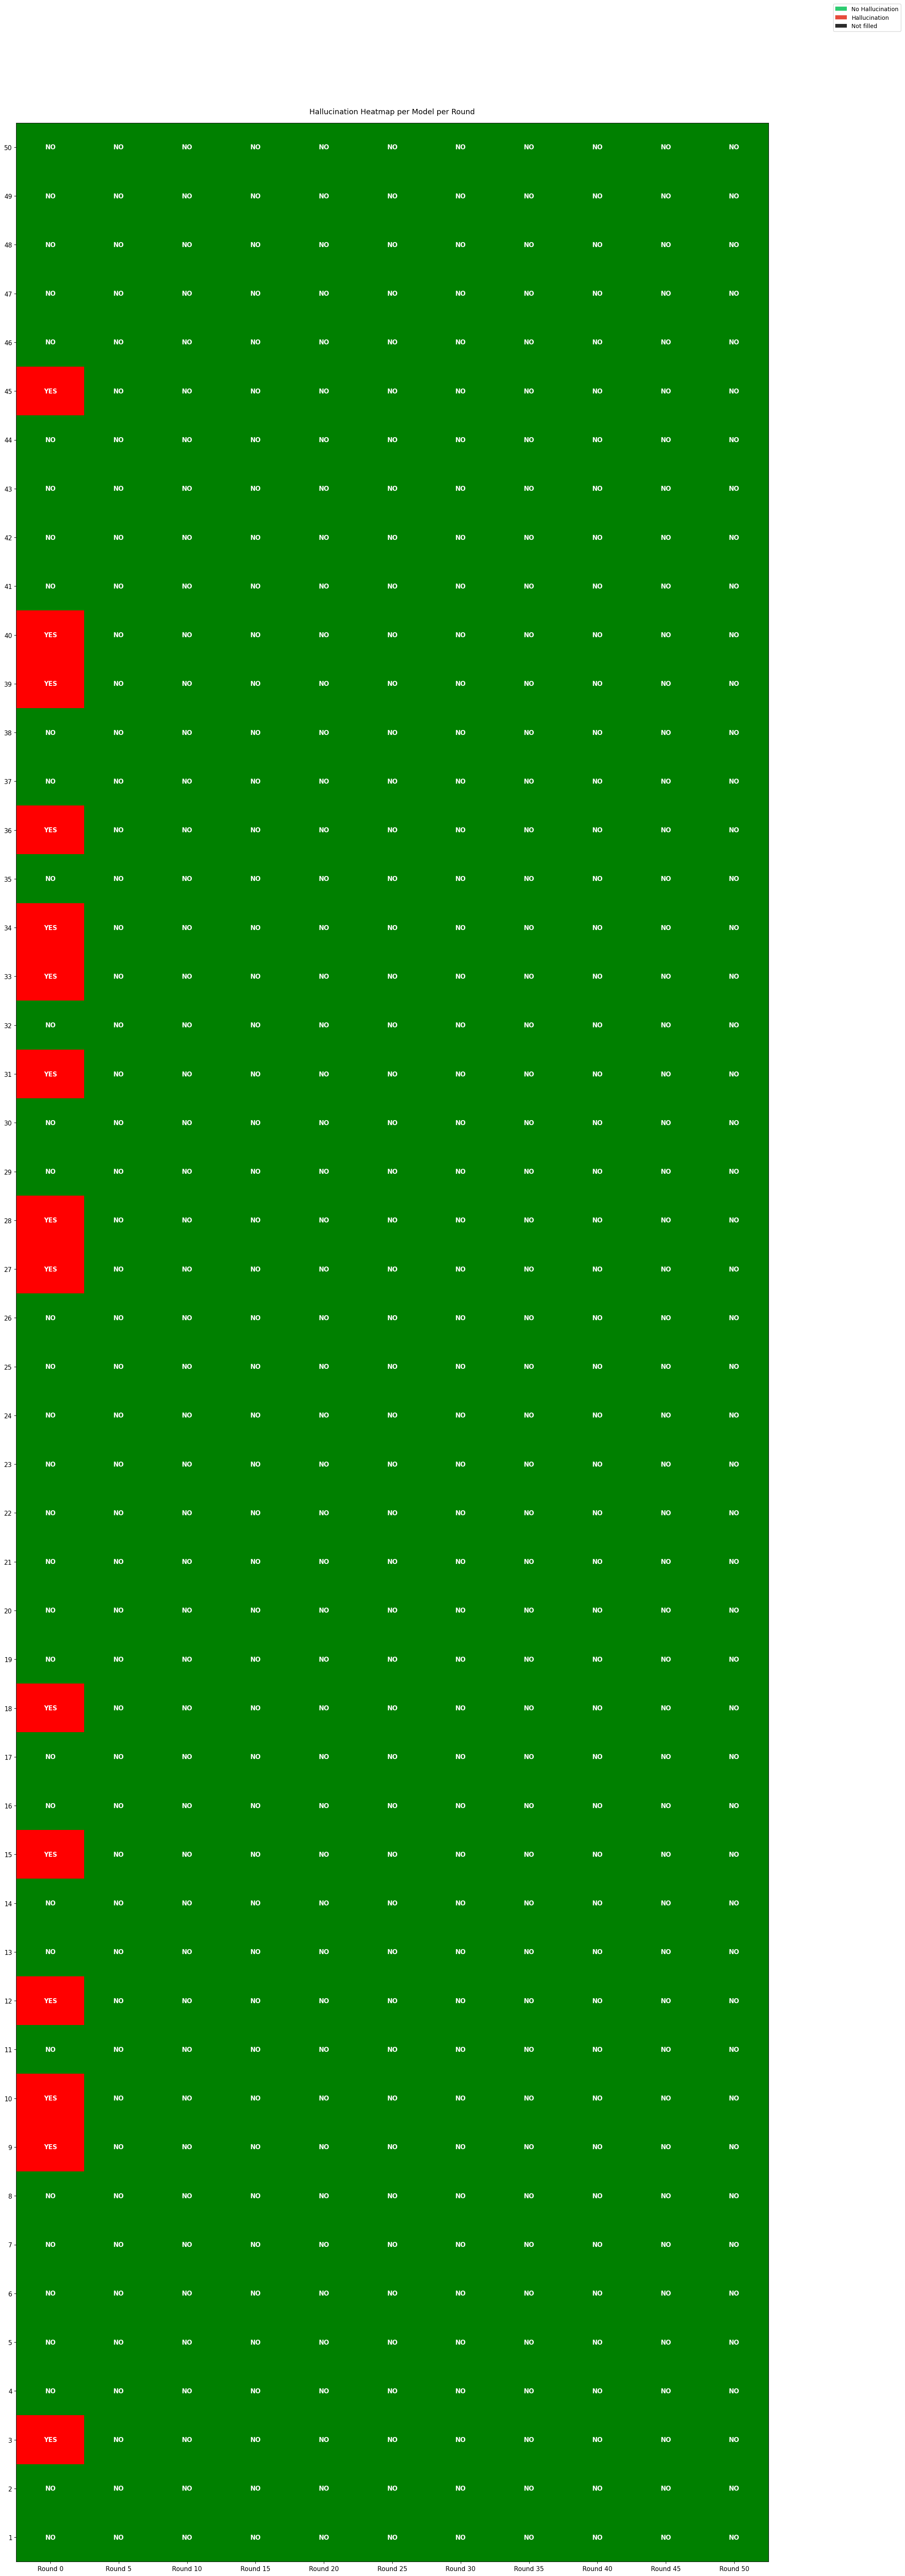

Saved to hallucination_heatmap.png


In [24]:


df = pd.read_csv("/content/output_9.csv")

df["Hallucination"] = df["Hallucination"].str.strip().str.lower()
df["hall_val"] = df["Hallucination"].map({"yes": 1, "no": 0})

pivot = df.pivot_table(index="node", columns="round", values="hall_val", aggfunc="max")

node = pivot.index.tolist()
round = pivot.columns.tolist()
values = pivot.values

fig, ax = plt.subplots(figsize=(len(round) * 1.8 + 2, len(node) * 1.2 + 2))

cmap = mcolors.ListedColormap(["green", "red"])
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

import matplotlib.colors as mcolors

ax.set_facecolor("grey")

im = ax.imshow(values, cmap=cmap, norm=norm, aspect="auto",origin="lower")

for i in range(len(node)):
    for j in range(len(round)):
        val = values[i, j]
        if np.isnan(val):
            label = "?"
            color = "#888888"
        elif val == 1:
            label = "YES"
            color = "white"
        else:
            label = "NO"
            color = "white"
        ax.text(j, i, label, ha="center", va="center", fontsize=11,
                fontweight="bold", color=color)

ax.set_xticks(range(len(round)))
ax.set_xticklabels([f"Round {r}" for r in round], fontsize=11)
ax.set_yticks(range(len(node)))
ax.set_yticklabels(node, fontsize=11)

ax.set_title("Hallucination Heatmap per Model per Round", fontsize=13, pad=16)

legend = [
    Patch(facecolor="#2ecc71", label="No Hallucination"),
    Patch(facecolor="#e74c3c", label="Hallucination"),
    Patch(facecolor="#2c2c2c", label="Not filled"),
]
ax.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.18, 1.05), fontsize=10)

plt.tight_layout()
plt.savefig("hallucination_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to hallucination_heatmap.png")

In [ ]:
from google.colab import files
files.download("hallucination_heatmap_v3.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Evaluation**

**Quantitative Metric: Shannon Entropy ($H$)**

* Benchmark: Shannon Entropy is the primary metric for assessing system-wide alignment.
* Application: The network's ``disorder'' is evaluated by treating the aggregate of agent responses as a probability distribution.
* Definition: For each communication round $t$, entropy is calculated as:
      \begin{equation}
        H(t) = -\sum_{i=1}^{n} P(x_i) \log_2 P(x_i)
      \end{equation}
  where $P(x_i)$ is the frequency of a unique response cluster $x_i$ appearing across the nodes.


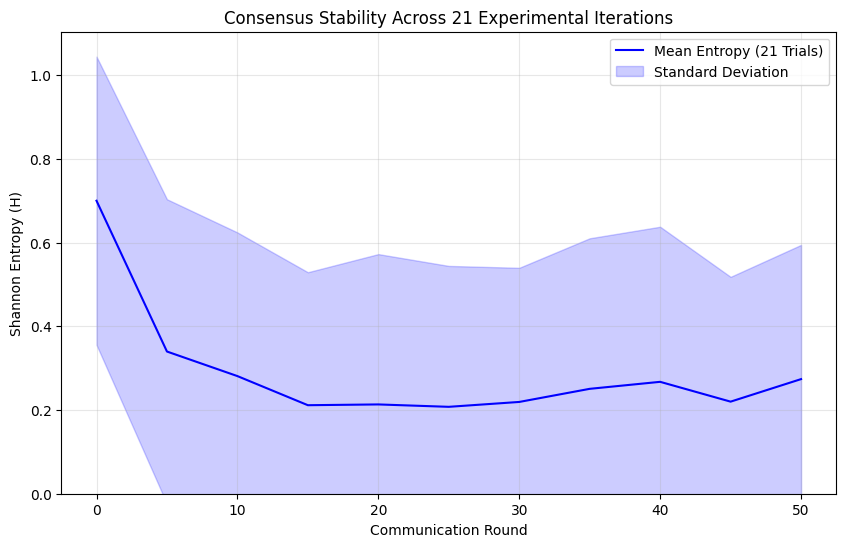

In [ ]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt

def calculate_shannon_entropy(series):
    probs = series.value_counts(normalize=True)
    return -sum(probs * np.log2(probs))

all_files = glob.glob("output_*.csv")

all_entropy_stats = []

for file in all_files:
    df = pd.read_csv(file)
    round_entropy = df.groupby('round')['Hallucination'].apply(calculate_shannon_entropy)
    all_entropy_stats.append(round_entropy)

entropy_matrix = pd.concat(all_entropy_stats, axis=1)

mean_entropy = entropy_matrix.mean(axis=1)
std_entropy = entropy_matrix.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(mean_entropy.index, mean_entropy, color='blue', label='Mean Entropy (21 Trials)')
plt.fill_between(mean_entropy.index,
                 mean_entropy - std_entropy,
                 mean_entropy + std_entropy,
                 color='blue', alpha=0.2, label='Standard Deviation')

plt.title("Consensus Stability Across 21 Experimental Iterations")
plt.xlabel("Communication Round")
plt.ylabel("Shannon Entropy (H)")
plt.ylim(0, None)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("aggregated_entropy.png", dpi=300)
plt.show()

*The Aggregated Hallucination Probability Map provides a granular, node-level visualization of the "micro-to-macro" transition. In Round 0, the map displays high probability error clusters, which reflect the baseline stochastic independence of the uncoordinated 50-node network. As communication rounds progress, the probability gradient across the nodes shifts significantly toward a stable "green" state. This visual transition confirms that the iterative structural pressure of the topology successfully filters out individual agent hallucinations.*

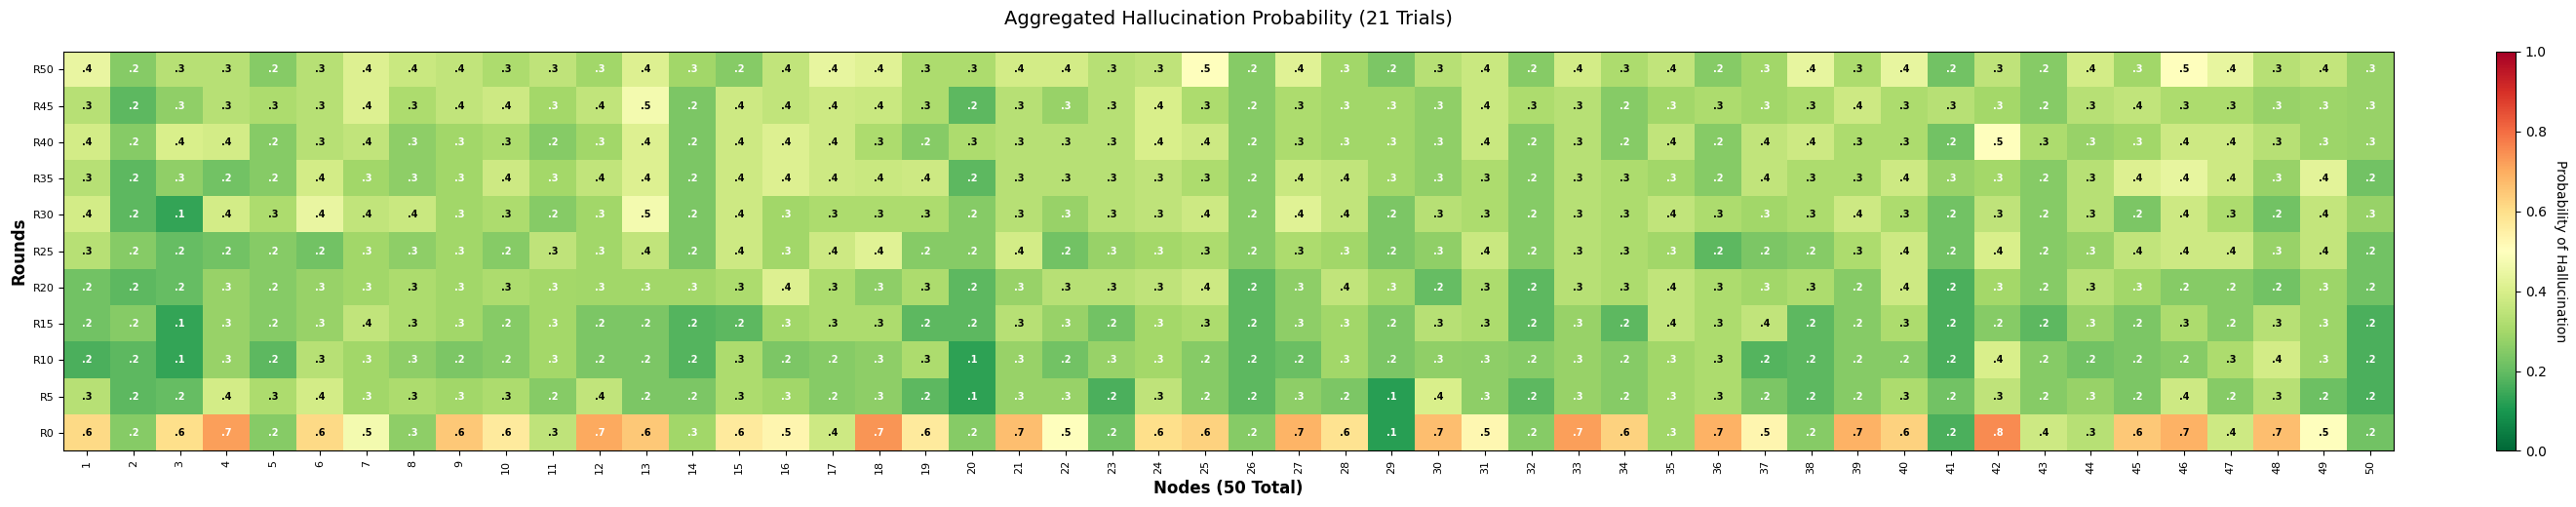

In [ ]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

all_files = glob.glob("output_*.csv")
all_trials = []

for file in all_files:
    temp_df = pd.read_csv(file)
    temp_df["Hallucination"] = temp_df["Hallucination"].str.strip().str.lower()
    temp_df["hall_val"] = temp_df["Hallucination"].map({"yes": 1, "no": 0})
    all_trials.append(temp_df)

combined_df = pd.concat(all_trials)
pivot = combined_df.pivot_table(index="round", columns="node", values="hall_val", aggfunc="mean")

rounds = pivot.index.tolist()
nodes = pivot.columns.tolist()
values = pivot.values

fig, ax = plt.subplots(figsize=(len(nodes) * 0.5 + 2, len(rounds) * 0.3 + 2))
cmap = plt.cm.RdYlGn_r
cmap.set_bad(color='#2c2c2c')

im = ax.imshow(values, cmap=cmap, aspect="auto", origin="lower", vmin=0, vmax=1)

for i in range(len(rounds)):
    for j in range(len(nodes)):
        val = values[i, j]
        if not np.isnan(val):
            label = f"{val:.1f}".replace("0.", ".") if val > 0 else "0"
            color = "black" if 0.3 < val < 0.7 else "white"
            ax.text(j, i, label, ha="center", va="center",
                    fontsize=7, fontweight="bold", color=color)

ax.set_xticks(range(len(nodes)))
ax.set_xticklabels(nodes, fontsize=8, rotation=90)
ax.set_yticks(range(len(rounds)))
ax.set_yticklabels([f"R{r}" for r in rounds], fontsize=8)

ax.set_ylabel("Rounds", fontsize=12, fontweight="bold")
ax.set_xlabel("Nodes (50 Total)", fontsize=12, fontweight="bold")
ax.set_title("Aggregated Hallucination Probability (21 Trials)", fontsize=14, pad=20)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Probability of Hallucination', rotation=270, labelpad=15)
plt.tight_layout()
plt.savefig("aggregated_hallucination_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

*To quantify the statistical certainty of this transition, a Normal Distribution (Gaussian) analysis was conducted on the final-round entropy results across all 21 trials. This analysis evaluates whether the observed convergence is a robust property of the architecture rather than a result of specific random initializations*

Calculated Mean (μ): 0.2738 bits
Calculated Std Dev (σ): 0.3207 bits


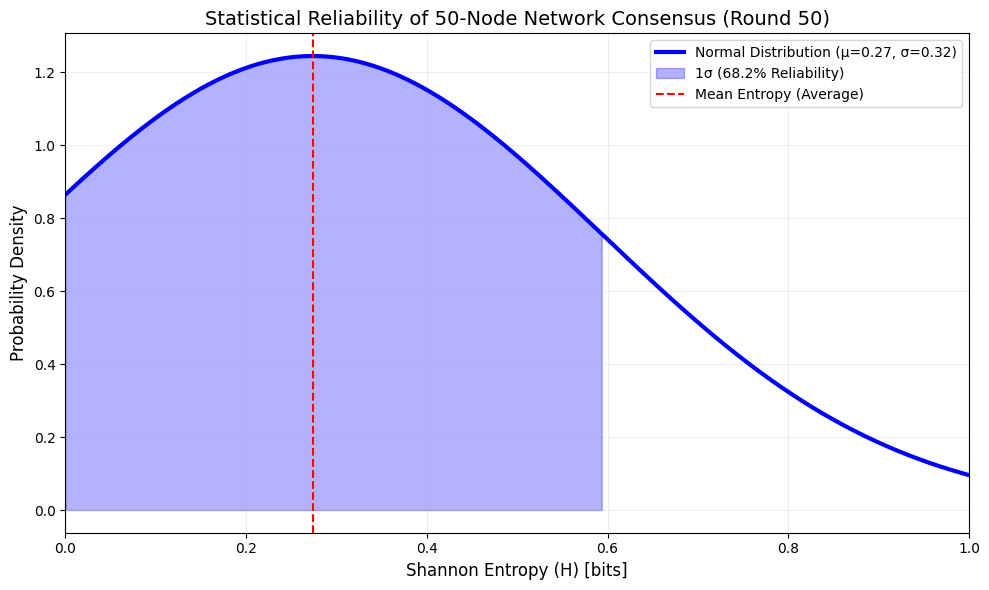

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

final_round_data = entropy_matrix.iloc[-1]
mu = final_round_data.mean()
sigma = final_round_data.std(ddof=1)

print(f"Calculated Mean (μ): {mu:.4f} bits")
print(f"Calculated Std Dev (σ): {sigma:.4f} bits")

x = np.linspace(0, 1.0, 1000)
y = stats.norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, color='blue', lw=3, label=f'Normal Distribution (μ={mu:.2f}, σ={sigma:.2f})')
plt.fill_between(x, 0, y, where=(x >= mu - sigma) & (x <= mu + sigma),
                 color='blue', alpha=0.3, label='1σ (68.2% Reliability)')
plt.axvline(mu, color='red', linestyle='--', label='Mean Entropy (Average)')
plt.title("Statistical Reliability of 50-Node Network Consensus (Round 50)", fontsize=14)
plt.xlabel("Shannon Entropy (H) [bits]", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

plt.xlim(0, 1.0)
plt.grid(True, alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig("final_consensus_bell_curve.png", dpi=300)
plt.show()